In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("shayanfazeli/heartbeat")

# print("Path to dataset files:", path)

# Scetch - what do we wanna include

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy

from persim.landscapes import PersLandscapeApprox, plot_landscape_simple

In [ ]:
def load_and_trim_signal(dataframe, class_label):
    """
    Extracts the first signal of a given class and trims trailing zeros.
    """
    # 187th column is the label in MIT-BIH
    signal = dataframe[dataframe.iloc[:, 187] == class_label].iloc[0, :187].values
    trimmed_signal = np.trim_zeros(signal, 'b')
    return trimmed_signal

def plot_tda_rationale(sig_normal, sig_abnormal):
    plots_dir = "ECG_plots"
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
        print(f"Created '{plots_dir}' directory")
    
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(sig_normal, color='#1f77b4', marker='o', markersize=3, linestyle='-', linewidth=1)
    ax1.set_title("Normal ECG Signal", fontsize=14)
    ax1.set_xlabel("Time (Samples)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    fig1.savefig(os.path.join(plots_dir, "01_normal_signal.png"), dpi=300, bbox_inches='tight')
    plt.close(fig1)
    print("Saved: 01_normal_signal.png")


    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.plot(sig_abnormal, color='#d62728', marker='o', markersize=3, linestyle='-', linewidth=1)
    ax2.set_title("Abnormal ECG Signal (Arrhythmia)", fontsize=14)
    ax2.set_xlabel("Time (Samples)")
    ax2.set_ylabel("Amplitude")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    fig2.savefig(os.path.join(plots_dir, "02_abnormal_signal.png"), dpi=300, bbox_inches='tight')
    plt.close(fig2)
    print("Saved: 02_abnormal_signal.png")


    embedder_3d = TakensEmbedding(time_delay=3, dimension=3)
    pc_norm_3d = embedder_3d.fit_transform(sig_normal.reshape(1, -1))[0]

    fig3 = plt.figure(figsize=(10, 8))
    ax3 = fig3.add_subplot(111, projection='3d')
    ax3.scatter(pc_norm_3d[:, 0], pc_norm_3d[:, 1], pc_norm_3d[:, 2], color='#1f77b4', s=15, alpha=0.7)
    ax3.plot(pc_norm_3d[:, 0], pc_norm_3d[:, 1], pc_norm_3d[:, 2], color='#1f77b4', linewidth=0.5, alpha=0.5)
    ax3.set_title("Phase Space Reconstruction (Normal)", fontsize=14)
    plt.tight_layout()
    fig3.savefig(os.path.join(plots_dir, "03_phase_space_normal.png"), dpi=300, bbox_inches='tight')
    plt.close(fig3)
    print("Saved: 03_phase_space_normal.png")


    pc_abnorm_3d = embedder_3d.fit_transform(sig_abnormal.reshape(1, -1))[0]

    fig4 = plt.figure(figsize=(10, 8))
    ax4 = fig4.add_subplot(111, projection='3d')
    ax4.scatter(pc_abnorm_3d[:, 0], pc_abnorm_3d[:, 1], pc_abnorm_3d[:, 2], color='#d62728', s=15, alpha=0.7)
    ax4.plot(pc_abnorm_3d[:, 0], pc_abnorm_3d[:, 1], pc_abnorm_3d[:, 2], color='#d62728', linewidth=0.5, alpha=0.5)
    ax4.set_title("Phase Space Reconstruction (Abnormal)", fontsize=14)
    plt.tight_layout()
    fig4.savefig(os.path.join(plots_dir, "04_phase_space_abnormal.png"), dpi=300, bbox_inches='tight')
    plt.close(fig4)
    print("Saved: 04_phase_space_abnormal.png")


    embedder = TakensEmbedding(time_delay=3, dimension=4)
    vr_pers = VietorisRipsPersistence(homology_dimensions=[0, 1])
    entropy_calc = PersistenceEntropy(normalize=True)

    pc_norm = embedder.fit_transform(sig_normal.reshape(1, -1))
    pc_abnorm = embedder.fit_transform(sig_abnormal.reshape(1, -1))
    
    diag_norm = vr_pers.fit_transform(pc_norm)
    diag_abnorm = vr_pers.fit_transform(pc_abnorm)
    
    ent_norm = entropy_calc.fit_transform(diag_norm)[0]
    ent_abnorm = entropy_calc.fit_transform(diag_abnorm)[0]

    dgm_norm_flat = diag_norm[0]
    ripser_dgm_norm = [dgm_norm_flat[dgm_norm_flat[:, 2] == d][:, :2] for d in [0, 1]]

    dgm_abnorm_flat = diag_abnorm[0]
    ripser_dgm_abnorm = [dgm_abnorm_flat[dgm_abnorm_flat[:, 2] == d][:, :2] for d in [0, 1]]


    fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5))
    fig5.suptitle(f'Normal ECG - Persistence Landscapes (Entropy $H_0$: {ent_norm[0]:.4f} | $H_1$: {ent_norm[1]:.4f})', fontsize=14)
    
    for idx, hom_deg in enumerate([0, 1]):
        if hom_deg < len(ripser_dgm_norm):
            dgm_for_deg = ripser_dgm_norm[hom_deg]
            
            finite_dgm = dgm_for_deg[dgm_for_deg[:, 1] != np.inf]
            
            if len(finite_dgm) > 0:
                pla = PersLandscapeApprox(dgms=[finite_dgm], hom_deg=0)
                plot_landscape_simple(
                    pla, 
                    ax=axes5[idx], 
                    alpha=0.5,
                    title=f'$H_{hom_deg}$ Landscape', 
                    depth_range=range(4) # Limits plot to the top 4 lambda functions
                )                
            else:
                axes5[idx].set_title(f'$H_{hom_deg}$ - No finite features')
                axes5[idx].axis('off')
        else:
            axes5[idx].set_title(f'$H_{hom_deg}$ - Dimension not computed')
            axes5[idx].axis('off')
            
    plt.tight_layout()
    fig5.savefig(os.path.join(plots_dir, "05_landscape_normal.png"), dpi=300, bbox_inches='tight')
    plt.close(fig5)
    print("Saved: 05_landscape_normal.png")


    fig6, axes6 = plt.subplots(1, 2, figsize=(14, 5))
    fig6.suptitle(f'Abnormal ECG - Persistence Landscapes (Entropy $H_0$: {ent_abnorm[0]:.4f} | $H_1$: {ent_abnorm[1]:.4f})', fontsize=14)
    
    for idx, hom_deg in enumerate([0, 1]):
        if hom_deg < len(ripser_dgm_abnorm):
            dgm_for_deg = ripser_dgm_abnorm[hom_deg]
            
            finite_dgm = dgm_for_deg[dgm_for_deg[:, 1] != np.inf]
            
            if len(finite_dgm) > 0:
                pla = PersLandscapeApprox(dgms=[finite_dgm], hom_deg=0)
                plot_landscape_simple(
                    pla, 
                    ax=axes6[idx], 
                    alpha=0.5,
                    title=f'$H_{hom_deg}$ Landscape', 
                    depth_range=range(4) # Limits plot to the top 4 lambda functions
                )                
            else:
                axes6[idx].set_title(f'$H_{hom_deg}$ - No finite features')
                axes6[idx].axis('off')
        else:
            axes6[idx].set_title(f'$H_{hom_deg}$ - Dimension not computed')
            axes6[idx].axis('off')
            
    plt.tight_layout()
    fig6.savefig(os.path.join(plots_dir, "06_landscape_abnormal.png"), dpi=300, bbox_inches='tight')
    plt.close(fig6)
    print("Saved: 06_landscape_abnormal.png")
    


In [4]:
df = pd.read_csv("mitbih_train.csv", header=None)


sig_normal = load_and_trim_signal(df, 0.0)
sig_abnormal = load_and_trim_signal(df, 1.0)
plot_tda_rationale(sig_normal, sig_abnormal)

Saved: 01_normal_signal.png
Saved: 02_abnormal_signal.png
Saved: 03_phase_space_normal.png
Saved: 04_phase_space_abnormal.png
Saved: 05_landscape_normal.png
Saved: 06_landscape_abnormal.png


### Try with 0.05 training set

Optimal tau (AMI): 115


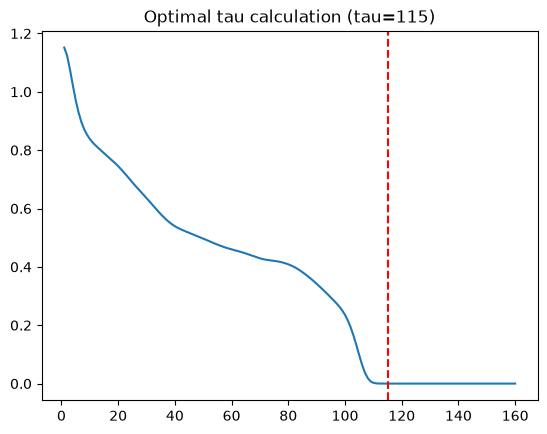

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

df = pd.read_csv("mitbih_train.csv", header=None, nrows=5000)
X = df.iloc[:, :-1].values

def compute_ami(sig, delay, bins=30): 
    y1 = sig[:-delay]
    y2 = sig[delay:]
    c_xy = np.histogram2d(y1, y2, bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)

max_delay = 160
delays = np.arange(1, max_delay + 1)

ami_results = []
for d in delays:
    ami_vals = [compute_ami(sig, d) for sig in X]
    ami_results.append(np.median(ami_vals))

smoothed_ami = gaussian_filter1d(ami_results, sigma=2)
local_minima = argrelmin(smoothed_ami)[0]

optimal_tau = local_minima[0] + 1 if len(local_minima) > 0 else 3

print(f"Optimal tau (AMI): {optimal_tau}")

plt.plot(delays, smoothed_ami)
plt.axvline(optimal_tau, color='r', linestyle='--')
plt.title(f"Optimal tau calculation (tau={optimal_tau})")
plt.show()

# Trying to find optimall embedding params

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin
from scipy.ndimage import gaussian_filter1d

def compute_ami(sig, delay, bins=1000):
    y1 = sig[:-delay]
    y2 = sig[delay:]
    c_xy = np.histogram2d(y1, y2, bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)

df = pd.read_csv("mitbih_train.csv", header=None, nrows=5000)
X = df.iloc[:, :-1].values

max_delay = 60
delays = np.arange(1, max_delay + 1)

ami_results = []
for d in delays:
    ami_vals = [compute_ami(sig, d) for sig in X]
    ami_results.append(np.median(ami_vals))


sigma_val = 2
smoothed_ami = gaussian_filter1d(ami_results, sigma=sigma_val)
local_minima = argrelmin(smoothed_ami)[0]

optimal_delay = local_minima[0] + 1 if len(local_minima) > 0 else 3

print(f"Optimal Time Delay (First Local Minimum): tau = {optimal_delay}")

plt.figure(figsize=(10, 6))
plt.plot(delays, ami_results, label='Raw AMI', alpha=0.3, color='gray')
plt.plot(delays, smoothed_ami, label=f'Smoothed AMI ($\sigma={sigma_val}$)', color='blue', linewidth=2)
plt.axvline(x=optimal_delay, color='red', linestyle='--', label=f'Optimal $\\tau$ = {optimal_delay}')
plt.title('Average Mutual Information (AMI) vs. Time Delay')
plt.xlabel('Time Delay ($\\tau$)')
plt.ylabel('AMI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("First 10 AMI values (Raw):", np.round(ami_results[:10], 4))
print("First 10 AMI values (Smoothed):", np.round(smoothed_ami[:10], 4))

KeyboardInterrupt: 

i=0, Completed bins=4
i=1, Completed bins=5
i=2, Completed bins=6
i=3, Completed bins=7
i=4, Completed bins=10
i=5, Completed bins=20
i=6, Completed bins=30
i=7, Completed bins=40
i=8, Completed bins=100
i=9, Completed bins=200


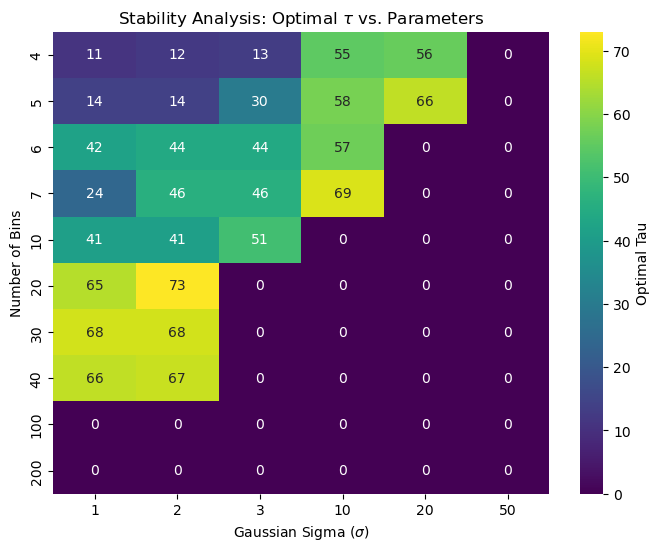

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from scipy.signal import argrelmin
from scipy.ndimage import gaussian_filter1d
import seaborn as sns

df = pd.read_csv("mitbih_train.csv", header=None, nrows=1000)
X = df.iloc[:, :-1].values

def compute_ami(sig, delay, bins):
    y1 = sig[:-delay]
    y2 = sig[delay:]
    c_xy = np.histogram2d(y1, y2, bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)

bins_list = [4, 5, 6, 7, 10, 20, 30, 40, 100, 200]
sigma_list = [1, 2, 3, 10, 20, 50]
max_delay = 100
delays = np.arange(1, max_delay + 1)

tau_matrix = np.zeros((len(bins_list), len(sigma_list)))

for i, bins in enumerate(bins_list):
    ami_results = []
    for d in delays:
        ami_vals = [compute_ami(sig, d, bins) for sig in X[:200]] 
        ami_results.append(np.median(ami_vals))
        
    for j, sigma in enumerate(sigma_list):
        smoothed = gaussian_filter1d(ami_results, sigma=sigma)
        minima = argrelmin(smoothed)[0]
        tau = minima[0] + 1 if len(minima) > 0 else 0
        tau_matrix[i, j] = tau
    print(f"i={i}, Completed bins={bins}")
plt.figure(figsize=(8, 6))
sns.heatmap(tau_matrix, annot=True, xticklabels=sigma_list, yticklabels=bins_list, 
            cmap="viridis", fmt=".0f", cbar_kws={'label': 'Optimal Tau'})
plt.title("Stability Analysis: Optimal $\\tau$ vs. Parameters")
plt.xlabel("Gaussian Sigma ($\sigma$)")
plt.ylabel("Number of Bins")
plt.show()

# Final results 
### Here we have embedding of 3 and below we have ``an optimal'' embedding

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from gtda.homology import CubicalPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve
from gtda.diagrams import Filtering

def load_data(file_path, sample_frac=1.0):
    df = pd.read_csv(file_path, header=None)
    
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].astype(int).values
    
    if sample_frac < 1.0:
        X, _, y, _ = train_test_split(
            X, y, 
            train_size=sample_frac, 
            stratify=y, 
            random_state=42
        )
    return X, y

def flatten_3d_to_2d(X):
    return X.reshape(X.shape[0], -1)

def main():
    X_train, y_train = load_data("mitbih_train.csv", sample_frac=1.0) 
    X_test, y_test   = load_data("mitbih_test.csv", sample_frac=1.0)
    
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples:  {X_test.shape[0]}")
    
    target_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
    
    passthrough = FunctionTransformer(lambda x: x)
    flattener = FunctionTransformer(flatten_3d_to_2d)

    
    clf_baseline = RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"
    )
    clf_baseline.fit(X_train, y_train)
    
    print("\n--- Classification Report: BASELINE ---")
    print(classification_report(y_test, clf_baseline.predict(X_test), target_names=target_names))

    
    takens_vr_pipeline = Pipeline([
        ("embedding", TakensEmbedding(time_delay=3, dimension=3)),
        ("topology", VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
        ("features", FeatureUnion([
            ("entropy", PersistenceEntropy(normalize=True)),
            ("amplitude", Amplitude(metric="wasserstein")),
            ("betti_H0", Pipeline([
                ("filter", Filtering(homology_dimensions=[0])),
                ("curve", BettiCurve(n_bins=50)), 
                ("flatten", flattener)
            ])),
            
            ("betti_H1", Pipeline([
                ("filter", Filtering(homology_dimensions=[1])),
                ("curve", BettiCurve(n_bins=20)), 
                ("flatten", flattener)
            ]))
        ]))
    ])
    
    model_takens = Pipeline([
        ("all_features", FeatureUnion([
            ("raw", passthrough), 
            ("tda", takens_vr_pipeline)
        ])),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"))
    ])
    
    model_takens.fit(X_train, y_train)
    
    print("\n--- Classification Report: HYBRID TAKENS+VR ---")
    print(classification_report(y_test, model_takens.predict(X_test), target_names=target_names))

if __name__ == "__main__":
    main()

1. Loading datasets (50% Train, 100% Test)...
Training samples: 87554
Testing samples:  21892

TRAINING: BASELINE (Standard Random Forest)

--- Classification Report: BASELINE ---
                      precision    recall  f1-score   support

          Normal (N)       0.97      1.00      0.98     18118
Supraventricular (S)       0.97      0.59      0.73       556
     Ventricular (V)       0.98      0.88      0.93      1448
          Fusion (F)       0.82      0.58      0.68       162
         Unknown (Q)       1.00      0.94      0.97      1608

            accuracy                           0.97     21892
           macro avg       0.95      0.80      0.86     21892
        weighted avg       0.97      0.97      0.97     21892


TRAINING: HYBRID 2 (Raw Signal + Takens + Vietoris-Rips TDA)
This might take a while depending on your CPU...

--- Classification Report: HYBRID TAKENS+VR ---
                      precision    recall  f1-score   support

          Normal (N)       0.97     

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from gtda.homology import CubicalPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve
from gtda.diagrams import Filtering

def load_data(file_path, sample_frac=1.0):
    df = pd.read_csv(file_path, header=None)
    
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].astype(int).values
    
    if sample_frac < 1.0:
        X, _, y, _ = train_test_split(
            X, y, 
            train_size=sample_frac, 
            stratify=y, 
            random_state=42
        )
    return X, y

def flatten_3d_to_2d(X):
    return X.reshape(X.shape[0], -1)

def clean_inf_to_nan(X):
    X[np.isinf(X)] = np.nan
    return X

def main():
    X_train, y_train = load_data("mitbih_train.csv", sample_frac=1.0) 
    X_test, y_test   = load_data("mitbih_test.csv", sample_frac=1.0)
    
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples:  {X_test.shape[0]}")
    
    target_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
    
    passthrough = FunctionTransformer(lambda x: x)
    flattener = FunctionTransformer(flatten_3d_to_2d)

    
    clf_baseline = RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"
    )
    clf_baseline.fit(X_train, y_train)
    
    print("\n--- Classification Report: BASELINE ---")
    print(classification_report(y_test, clf_baseline.predict(X_test), target_names=target_names))

    
    takens_vr_pipeline = Pipeline([
        ("embedding", TakensEmbedding(time_delay=5, dimension=3)),
        ("topology", VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
        ("features", FeatureUnion([
            ("entropy", PersistenceEntropy(normalize=True)),
            ("amplitude", Amplitude(metric="wasserstein")),
            ("betti_H0", Pipeline([
                ("filter", Filtering(homology_dimensions=[0])),
                ("curve", BettiCurve(n_bins=50)), 
                ("flatten", flattener)
            ])),
            
            ("betti_H1", Pipeline([
                ("filter", Filtering(homology_dimensions=[1])),
                ("curve", BettiCurve(n_bins=20)), 
                ("flatten", flattener)
            ]))
        ]))
    ])
    
    model_takens = Pipeline([
        ("all_features", FeatureUnion([
            ("raw", passthrough), 
            ("tda", takens_vr_pipeline)
        ])),
        ("cleaner", FunctionTransformer(clean_inf_to_nan)),
        ("imputer", SimpleImputer(strategy="mean")),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"))
    ])
    
    model_takens.fit(X_train, y_train)
    
    print("\n--- Classification Report: HYBRID TAKENS+VR ---")
    print(classification_report(y_test, model_takens.predict(X_test), target_names=target_names))

if __name__ == "__main__":
    main()

Training samples: 87554
Testing samples:  21892

TRAINING: BASELINE (Standard Random Forest)

--- Classification Report: BASELINE ---
                      precision    recall  f1-score   support

          Normal (N)       0.97      1.00      0.98     18118
Supraventricular (S)       0.97      0.59      0.73       556
     Ventricular (V)       0.98      0.88      0.93      1448
          Fusion (F)       0.82      0.58      0.68       162
         Unknown (Q)       1.00      0.94      0.97      1608

            accuracy                           0.97     21892
           macro avg       0.95      0.80      0.86     21892
        weighted avg       0.97      0.97      0.97     21892


TRAINING: HYBRID 2 (Raw Signal + Takens + Vietoris-Rips TDA)
This might take a while depending on your CPU...

--- Classification Report: HYBRID TAKENS+VR ---
                      precision    recall  f1-score   support

          Normal (N)       0.97      1.00      0.98     18118
Supraventricular (S)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve, Filtering

def load_data(file_path, sample_frac=1.0):
    df = pd.read_csv(file_path, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].astype(int).values
    
    if sample_frac < 1.0:
        X, _, y, _ = train_test_split(
            X, y, train_size=sample_frac, stratify=y, random_state=42
        )
    return X, y

def flatten_3d_to_2d(X):
    return X.reshape(X.shape[0], -1)

def clean_inf_to_nan(X):
    X_clean = np.copy(X)
    X_clean[np.isinf(X_clean)] = np.nan
    return X_clean

def main():
    X_train, y_train = load_data("mitbih_train.csv", sample_frac=1.0) 
    X_test, y_test   = load_data("mitbih_test.csv", sample_frac=1.0)
    
    target_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
    
    passthrough = FunctionTransformer(lambda x: x)
    flattener = FunctionTransformer(flatten_3d_to_2d)

    
    clf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
    clf_baseline.fit(X_train, y_train)
    
    print("\n--- Classification Report: BASELINE ---")
    print(classification_report(y_test, clf_baseline.predict(X_test), target_names=target_names))

    takens_vr_pipeline = Pipeline([
        ("embedding", TakensEmbedding(time_delay=3, dimension=3)),
        ("topology", VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
        ("features", FeatureUnion([
            ("entropy", PersistenceEntropy(normalize=True)),
            ("amplitude", Amplitude(metric="wasserstein")),
            
            ("betti_H0", Pipeline([
                ("filter", Filtering(homology_dimensions=[0])),
                ("curve", BettiCurve(n_bins=50)), 
                ("flatten", flattener)
            ])),
            
            ("betti_H1", Pipeline([
                ("filter", Filtering(homology_dimensions=[1])),
                ("curve", BettiCurve(n_bins=20)), 
                ("flatten", flattener)
            ]))
        ]))
    ])
    
    model_takens = Pipeline([
        ("all_features", FeatureUnion([
            ("raw", passthrough), 
            ("tda", takens_vr_pipeline)
        ])),
        ("cleaner", FunctionTransformer(clean_inf_to_nan)),
        ("imputer", SimpleImputer(strategy="mean")),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"))
    ])
    
    model_takens.fit(X_train, y_train)
    
    print("\n--- Classification Report: HYBRID TAKENS+VR ---")
    print(classification_report(y_test, model_takens.predict(X_test), target_names=target_names))

if __name__ == "__main__":
    main()

1. Loading datasets...

TRAINING: BASELINE (Standard Random Forest)

--- Classification Report: BASELINE ---
                      precision    recall  f1-score   support

          Normal (N)       0.97      1.00      0.98     18118
Supraventricular (S)       0.97      0.59      0.73       556
     Ventricular (V)       0.98      0.88      0.93      1448
          Fusion (F)       0.82      0.58      0.68       162
         Unknown (Q)       1.00      0.94      0.97      1608

            accuracy                           0.97     21892
           macro avg       0.95      0.80      0.86     21892
        weighted avg       0.97      0.97      0.97     21892


TRAINING: HYBRID (Raw Signal + Takens + Vietoris-Rips TDA)

--- Classification Report: HYBRID TAKENS+VR ---
                      precision    recall  f1-score   support

          Normal (N)       0.97      1.00      0.99     18118
Supraventricular (S)       0.97      0.58      0.73       556
     Ventricular (V)       0.98   

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve, Filtering

def load_data(file_path, sample_frac=1.0):
    df = pd.read_csv(file_path, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].astype(int).values
    
    if sample_frac < 1.0:
        X, _, y, _ = train_test_split(
            X, y, train_size=sample_frac, stratify=y, random_state=42
        )
    return X, y

def flatten_3d_to_2d(X):
    return X.reshape(X.shape[0], -1)

def clean_inf_to_nan(X):
    X_clean = np.copy(X)
    X_clean[np.isinf(X_clean)] = np.nan
    return X_clean

def main():
    X_train, y_train = load_data("mitbih_train.csv", sample_frac=1.0) 
    X_test, y_test   = load_data("mitbih_test.csv", sample_frac=1.0)
    
    target_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
    
    passthrough = FunctionTransformer(lambda x: x)
    flattener = FunctionTransformer(flatten_3d_to_2d)


    clf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
    clf_baseline.fit(X_train, y_train)
    
    print("\n--- Classification Report: BASELINE ---")
    print(classification_report(y_test, clf_baseline.predict(X_test), target_names=target_names))

    
    takens_vr_pipeline = Pipeline([
        ("embedding", TakensEmbedding(time_delay=3, dimension=3)),
        ("topology", VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
        ("features", FeatureUnion([
            ("entropy", PersistenceEntropy(normalize=True)),
            
            ("betti_H0", Pipeline([
                ("filter", Filtering(homology_dimensions=[0])),
                ("curve", BettiCurve(n_bins=50)), 
                ("flatten", flattener)
            ])),
            
            ("betti_H1", Pipeline([
                ("filter", Filtering(homology_dimensions=[1])),
                ("curve", BettiCurve(n_bins=20)), 
                ("flatten", flattener)
            ]))
        ]))
    ])
    
    model_takens = Pipeline([
        ("all_features", FeatureUnion([
            ("raw", passthrough), 
            ("tda", takens_vr_pipeline)
        ])),
        ("cleaner", FunctionTransformer(clean_inf_to_nan)),
        ("imputer", SimpleImputer(strategy="mean")),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"))
    ])
    
    model_takens.fit(X_train, y_train)
    
    print("\n--- Classification Report: HYBRID TAKENS+VR ---")
    print(classification_report(y_test, model_takens.predict(X_test), target_names=target_names))

if __name__ == "__main__":
    main()

1. Loading datasets...

TRAINING: BASELINE (Standard Random Forest)

--- Classification Report: BASELINE ---
                      precision    recall  f1-score   support

          Normal (N)       0.97      1.00      0.98     18118
Supraventricular (S)       0.97      0.59      0.73       556
     Ventricular (V)       0.98      0.88      0.93      1448
          Fusion (F)       0.82      0.58      0.68       162
         Unknown (Q)       1.00      0.94      0.97      1608

            accuracy                           0.97     21892
           macro avg       0.95      0.80      0.86     21892
        weighted avg       0.97      0.97      0.97     21892


TRAINING: HYBRID (Raw Signal + Takens + Vietoris-Rips TDA)

--- Classification Report: HYBRID TAKENS+VR ---
                      precision    recall  f1-score   support

          Normal (N)       0.97      1.00      0.99     18118
Supraventricular (S)       0.97      0.59      0.73       556
     Ventricular (V)       0.98   